In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_style('darkgrid')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12

print("Libraries imported ✅")

Libraries imported ✅


In [2]:
df = pd.read_csv('C:/Users/Yashwanth u/Desktop/Data_projects/ab-testing/data/raw/ab_data_clean.csv')
df['timestamp'] = pd.to_datetime(df['timestamp'])

print("Shape:", df.shape)
df.head()

Shape: (290584, 8)


,user_id,timestamp,group,landing_page,converted,date,hour,day
0,851104,2017-01-21 22:11:48.556739,control,old_page,0,2017-01-21,22,Saturday
1,804228,2017-01-12 08:01:45.159739,control,old_page,0,2017-01-12,8,Thursday
2,661590,2017-01-11 16:55:06.154213,treatment,new_page,0,2017-01-11,16,Wednesday
3,853541,2017-01-08 18:28:03.143765,treatment,new_page,0,2017-01-08,18,Sunday
4,864975,2017-01-21 01:52:26.210827,control,old_page,1,2017-01-21,1,Saturday


📊 Conversion Rates by Group:
    Group  Conversions  Total Users  Conv Rate  Conv Rate %
  control        17489       145274   0.120386      12.0386
treatment        17264       145310   0.118808      11.8808


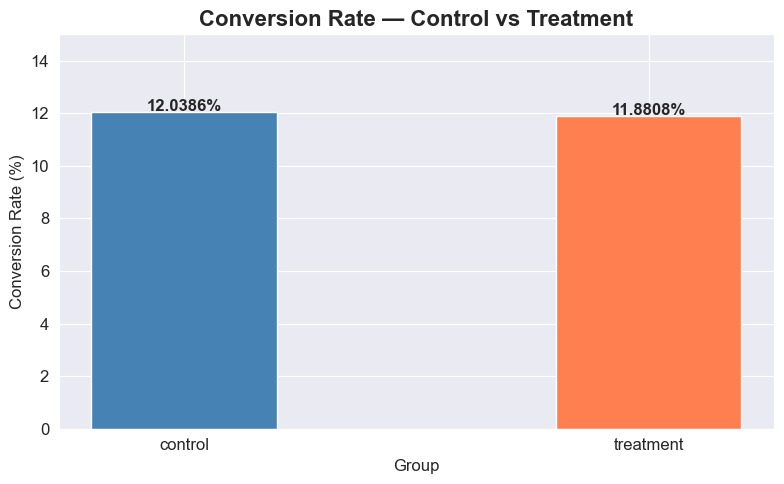


📌 Control Rate:   12.0386%
📌 Treatment Rate: 11.8808%
📌 Difference:     -0.1578%


In [3]:
# Business Question: Which group converts better?

conv_rates = df.groupby('group')['converted'].agg(['sum','count','mean']).reset_index()
conv_rates.columns = ['Group', 'Conversions', 'Total Users', 'Conv Rate']
conv_rates['Conv Rate %'] = (conv_rates['Conv Rate'] * 100).round(4)

print("📊 Conversion Rates by Group:")
print(conv_rates.to_string(index=False))

# Chart
fig, ax = plt.subplots(figsize=(8, 5))
colors = ['steelblue', 'coral']
bars = ax.bar(conv_rates['Group'],
              conv_rates['Conv Rate %'],
              color=colors, width=0.4)

for bar, val in zip(bars, conv_rates['Conv Rate %']):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.05,
            f'{val:.4f}%', ha='center',
            fontweight='bold', fontsize=12)

ax.set_title('Conversion Rate — Control vs Treatment',
             fontsize=16, fontweight='bold')
ax.set_xlabel('Group')
ax.set_ylabel('Conversion Rate (%)')
ax.set_ylim(0, 15)
plt.tight_layout()
plt.savefig('C:/Users/Yashwanth u/Desktop/Data_projects/ab-testing/data/raw/01_conv_rates.png', dpi=150)
plt.show()

control_rate = conv_rates[conv_rates['Group']=='control']['Conv Rate %'].values[0]
treatment_rate = conv_rates[conv_rates['Group']=='treatment']['Conv Rate %'].values[0]
diff = treatment_rate - control_rate
print(f"\n📌 Control Rate:   {control_rate:.4f}%")
print(f"📌 Treatment Rate: {treatment_rate:.4f}%")
print(f"📌 Difference:     {diff:.4f}%")

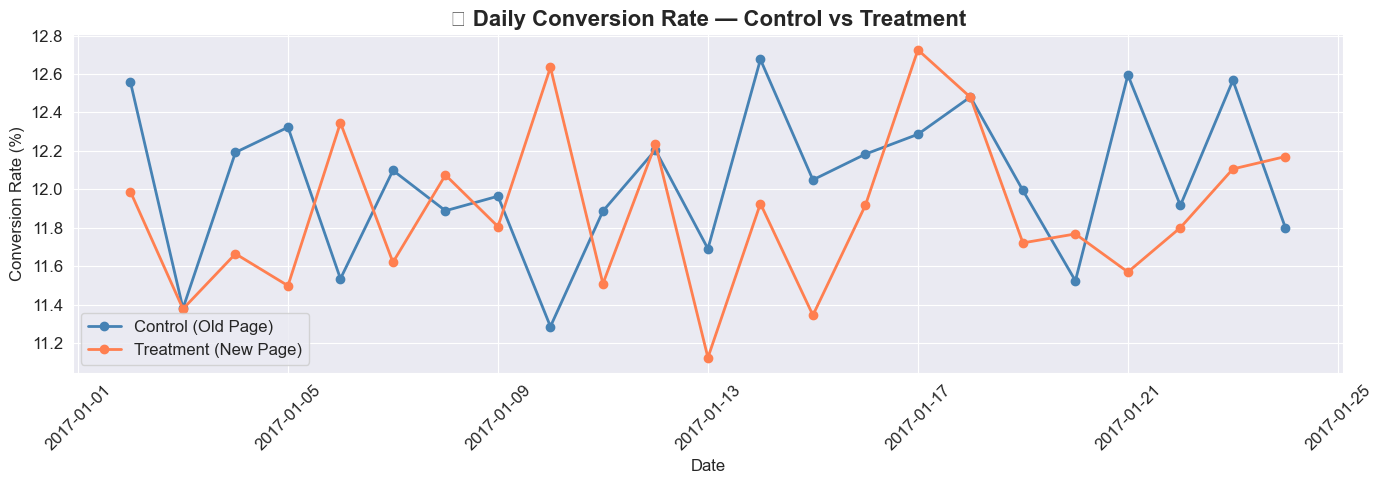

In [4]:
# Business Question: How did conversions trend daily?

daily = df.groupby(['date','group'])['converted'].mean().reset_index()
daily['date'] = pd.to_datetime(daily['date'])
daily['conv_rate'] = (daily['converted'] * 100).round(4)

control_daily   = daily[daily['group'] == 'control']
treatment_daily = daily[daily['group'] == 'treatment']

plt.figure(figsize=(14, 5))
plt.plot(control_daily['date'], control_daily['conv_rate'],marker='o', color='steelblue',linewidth=2, label='Control (Old Page)')
plt.plot(treatment_daily['date'], treatment_daily['conv_rate'],marker='o', color='coral',linewidth=2, label='Treatment (New Page)')

plt.title('📈 Daily Conversion Rate — Control vs Treatment',fontsize=16, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Conversion Rate (%)')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('C:/Users/Yashwanth u/Desktop/Data_projects/ab-testing/data/raw/02_daily_trend.png', dpi=150)
plt.show()

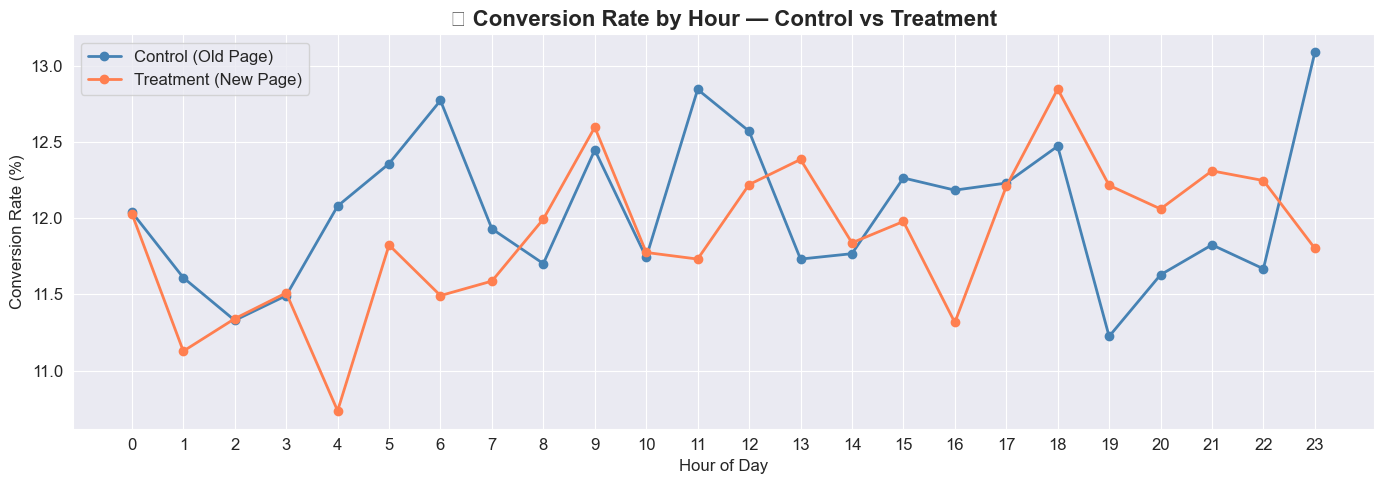

In [5]:
# Business Question: What time of day converts best?

hourly = df.groupby(['hour','group'])['converted'].mean().reset_index()
hourly['conv_rate'] = (hourly['converted'] * 100).round(4)

control_hourly   = hourly[hourly['group'] == 'control']
treatment_hourly = hourly[hourly['group'] == 'treatment']

plt.figure(figsize=(14, 5))
plt.plot(control_hourly['hour'], control_hourly['conv_rate'],
         marker='o', color='steelblue',
         linewidth=2, label='Control (Old Page)')
plt.plot(treatment_hourly['hour'], treatment_hourly['conv_rate'],
         marker='o', color='coral',
         linewidth=2, label='Treatment (New Page)')

plt.title('⏰ Conversion Rate by Hour — Control vs Treatment',
          fontsize=16, fontweight='bold')
plt.xlabel('Hour of Day')
plt.ylabel('Conversion Rate (%)')
plt.xticks(range(0, 24))
plt.legend()
plt.tight_layout()
plt.savefig('C:/Users/Yashwanth u/Desktop/Data_projects/ab-testing/data/raw/03_hourly_conv.png', dpi=150)
plt.show()

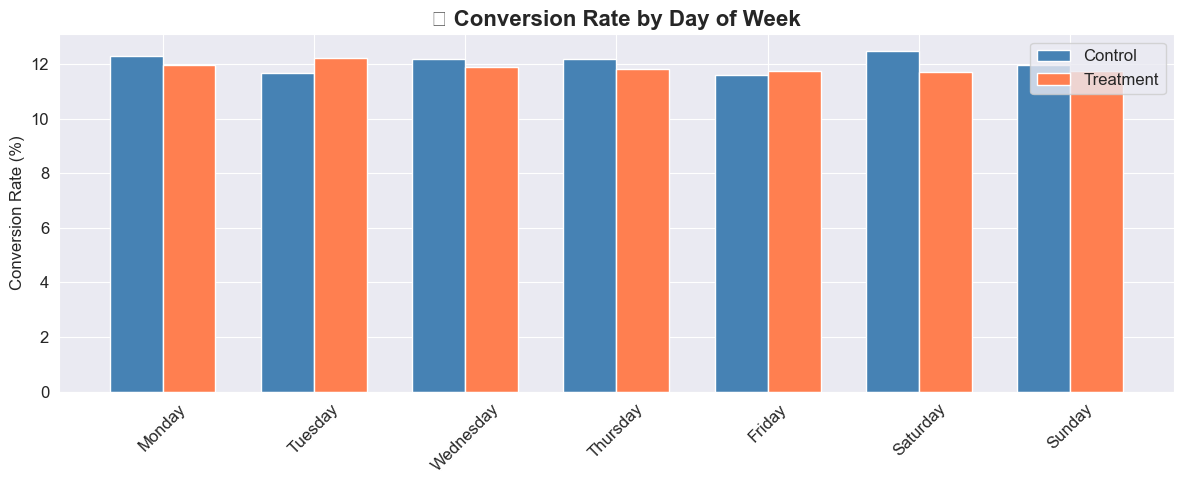

In [6]:
# Business Question: Which day of week converts best?

day_order = ['Monday','Tuesday','Wednesday',
             'Thursday','Friday','Saturday','Sunday']

day_conv = df.groupby(['day','group'])['converted'].mean().reset_index()
day_conv['conv_rate'] = (day_conv['converted'] * 100).round(4)

control_day   = day_conv[day_conv['group']=='control'].set_index('day').reindex(day_order)
treatment_day = day_conv[day_conv['group']=='treatment'].set_index('day').reindex(day_order)

x = np.arange(len(day_order))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - width/2, control_day['conv_rate'],
       width, label='Control', color='steelblue')
ax.bar(x + width/2, treatment_day['conv_rate'],
       width, label='Treatment', color='coral')

ax.set_xticks(x)
ax.set_xticklabels(day_order, rotation=45)
ax.set_title('📅 Conversion Rate by Day of Week',
             fontsize=16, fontweight='bold')
ax.set_ylabel('Conversion Rate (%)')
ax.legend()
plt.tight_layout()
plt.savefig('C:/Users/Yashwanth u/Desktop/Data_projects/ab-testing/data/raw/04_day_conv.png', dpi=150)
plt.show()

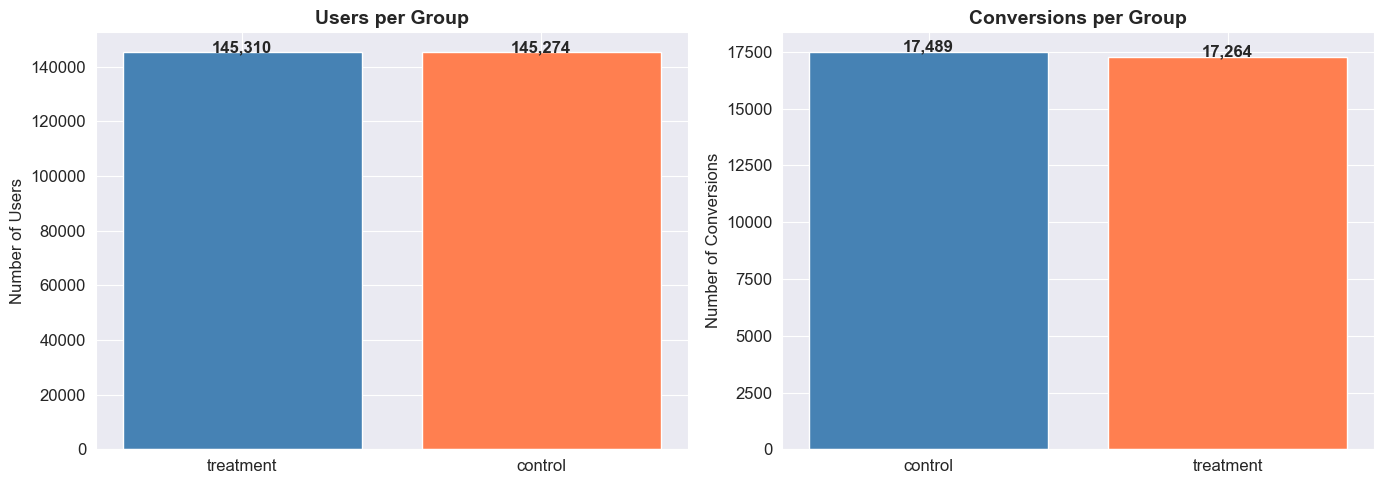

In [7]:
# Business Question: Is sample size balanced?

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Users per group
group_counts = df['group'].value_counts()
axes[0].bar(group_counts.index, group_counts.values,
            color=['steelblue','coral'])
for bar, val in zip(axes[0].patches, group_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 100,
                 f'{val:,}', ha='center', fontweight='bold')
axes[0].set_title('Users per Group', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Users')

# Conversions per group
conv_counts = df.groupby('group')['converted'].sum()
axes[1].bar(conv_counts.index, conv_counts.values,
            color=['steelblue','coral'])
for bar, val in zip(axes[1].patches, conv_counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 50,
                 f'{val:,}', ha='center', fontweight='bold')
axes[1].set_title('Conversions per Group', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Number of Conversions')

plt.tight_layout()
plt.savefig('C:/Users/Yashwanth u/Desktop/Data_projects/ab-testing/data/raw/05_volume.png', dpi=150)
plt.show()

In [8]:
control   = df[df['group'] == 'control']
treatment = df[df['group'] == 'treatment']

print("=" * 55)
print("📊 EDA SUMMARY — A/B TEST")
print("=" * 55)
print(f"Total Users          : {len(df):,}")
print(f"Control Users        : {len(control):,}")
print(f"Treatment Users      : {len(treatment):,}")
print(f"\nControl Conv Rate    : {control['converted'].mean()*100:.4f}%")
print(f"Treatment Conv Rate  : {treatment['converted'].mean()*100:.4f}%")
print(f"Difference           : {(treatment['converted'].mean() - control['converted'].mean())*100:.4f}%")
print(f"\nControl Conversions  : {control['converted'].sum():,}")
print(f"Treatment Conversions: {treatment['converted'].sum():,}")
print(f"\nTest Duration        : {df['timestamp'].min().date()} → {df['timestamp'].max().date()}")
print("=" * 55)
print("\n📌 Initial Observation:")
print("Treatment group shows slightly different conversion rate.")
print("But is this difference STATISTICALLY SIGNIFICANT?")
print("→ We find out in Phase 3 — Hypothesis Testing! 🎯")

📊 EDA SUMMARY — A/B TEST
Total Users          : 290,584
Control Users        : 145,274
Treatment Users      : 145,310

Control Conv Rate    : 12.0386%
Treatment Conv Rate  : 11.8808%
Difference           : -0.1578%

Control Conversions  : 17,489
Treatment Conversions: 17,264

Test Duration        : 2017-01-02 → 2017-01-24

📌 Initial Observation:
Treatment group shows slightly different conversion rate.
But is this difference STATISTICALLY SIGNIFICANT?
→ We find out in Phase 3 — Hypothesis Testing! 🎯
